In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [5]:
df =pd.read_csv('iris Dataset.csv')

In [6]:
data=load_iris()

In [7]:
x=data.data
y=data.target
names=data.target_names
print(names)

['setosa' 'versicolor' 'virginica']


In [8]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [9]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [11]:
# Convert the df into a Dataframe with columns highlighting feature names
df=pd.DataFrame(x,columns=data.feature_names)
df['class']=y 
df['class']=df['class'].replace(to_replace=['setosa', 'versicolor', 'virginica'], value=[0,1,2]) # Convert class names into numeric values
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
## Perform basic EDA.
## Note: There aren't any missing values in the dataset as mentioned, so no need to check for it.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [13]:
df.shape

(150, 5)

In [14]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
class                0
dtype: int64

In [15]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

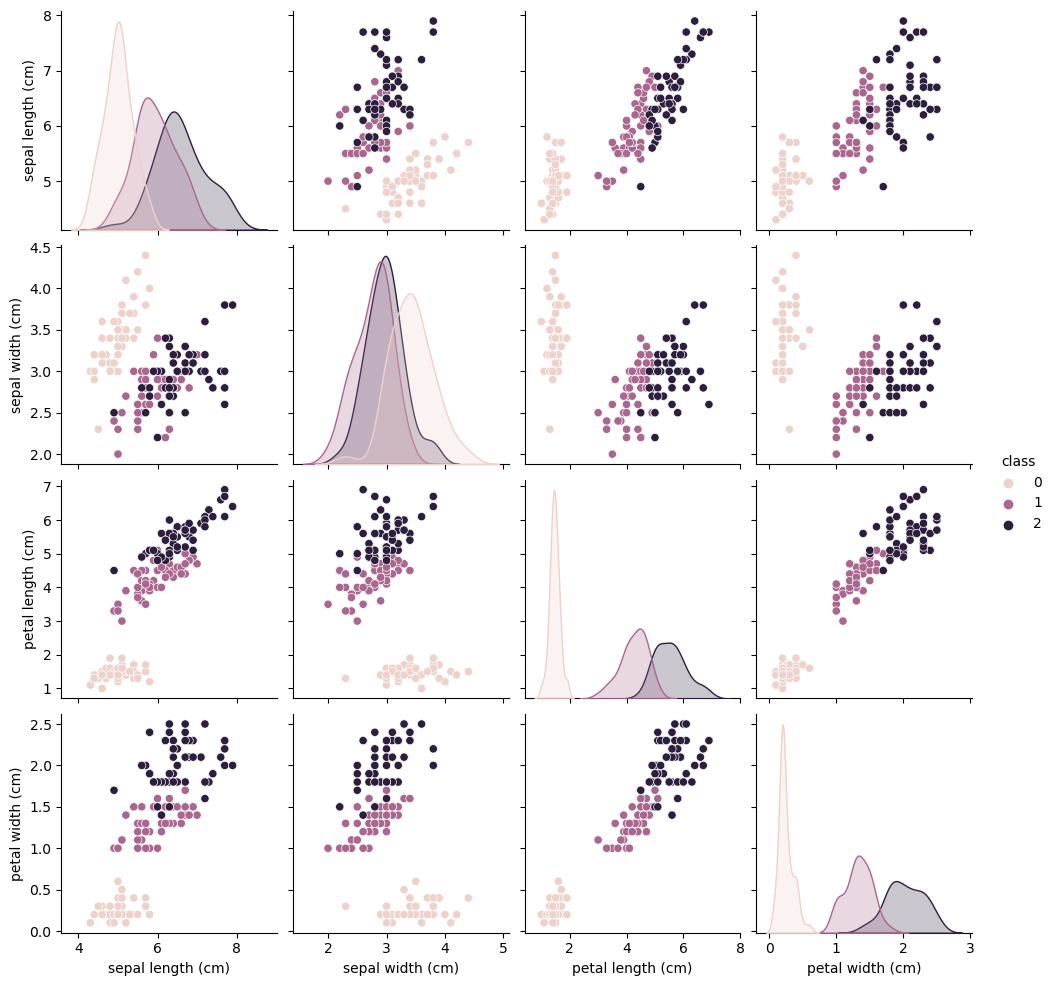

In [16]:
sns.pairplot(df, hue='class')

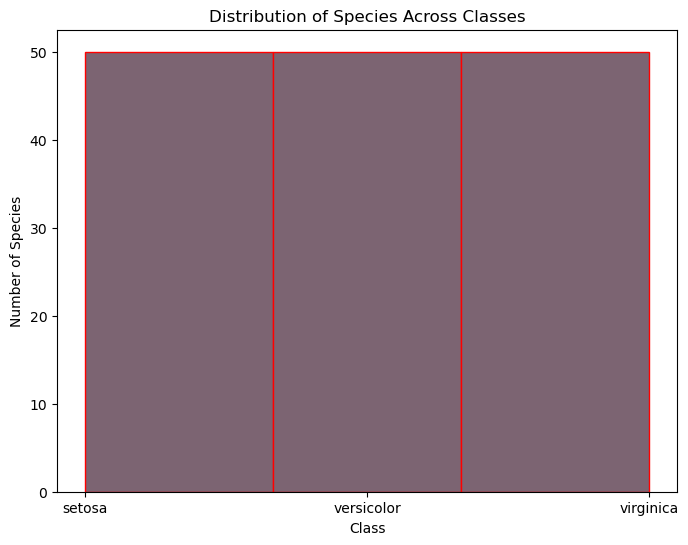

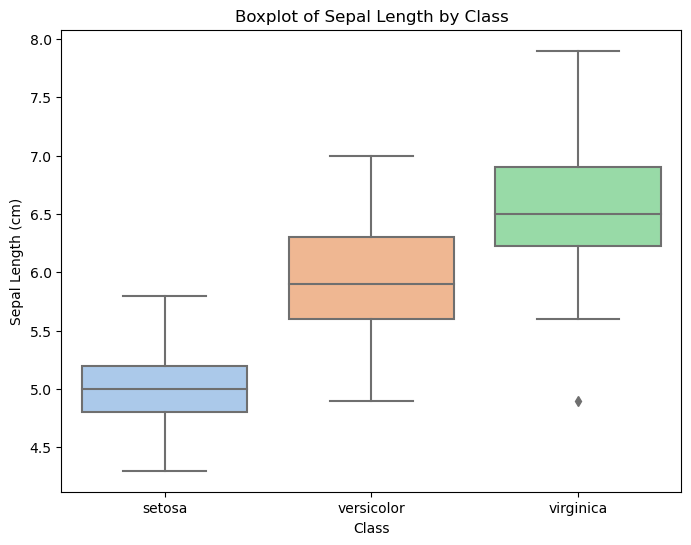

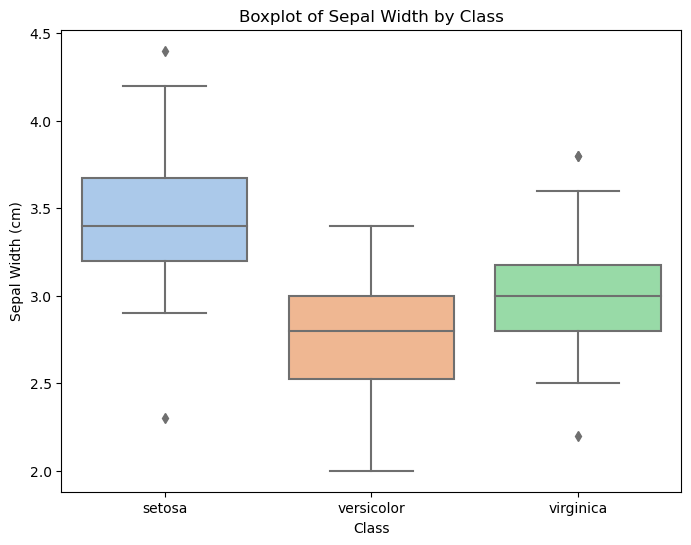

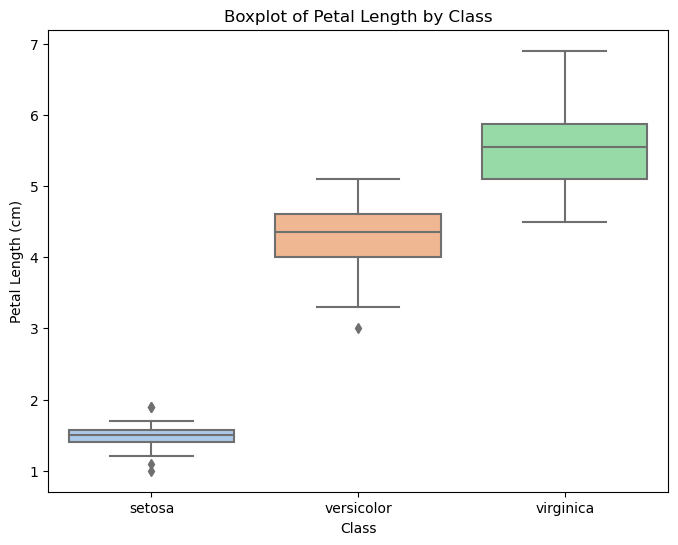

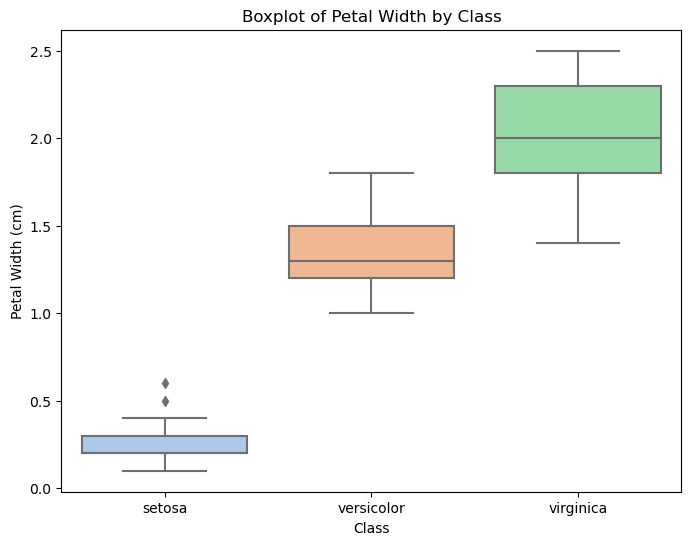

In [18]:
# Count the number of species in each class
class_counts = df['class'].value_counts()
sns.set_palette('pastel')
# Create a histogram
plt.figure(figsize=(8, 6))
plt.hist(df['class'], bins=3, edgecolor='Red', color='#7C6472')
plt.xlabel('Class')
plt.ylabel('Number of Species')
plt.title('Distribution of Species Across Classes')
plt.xticks(range(3), names)
plt.show()

# Create a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='class', y='sepal length (cm)', data=df) 
plt.xlabel('Class')
plt.ylabel('Sepal Length (cm)')
plt.title('Boxplot of Sepal Length by Class')
plt.xticks(range(3), names)
plt.show()

# Boxplot for other features (repeat for other features as needed)
plt.figure(figsize=(8, 6))
sns.boxplot(x='class', y='sepal width (cm)', data=df)
plt.xlabel('Class')
plt.ylabel('Sepal Width (cm)')
plt.title('Boxplot of Sepal Width by Class')
plt.xticks(range(3), names)
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='class', y='petal length (cm)', data=df)
plt.xlabel('Class')
plt.ylabel('Petal Length (cm)')
plt.title('Boxplot of Petal Length by Class')
plt.xticks(range(3), names)
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='class', y='petal width (cm)', data=df)
plt.xlabel('Class')
plt.ylabel('Petal Width (cm)')
plt.title('Boxplot of Petal Width by Class')
plt.xticks(range(3), names)
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [20]:
math.sqrt(len(y_test)) # Round off the values to floor or ceiling value, here k=5

5.477225575051661

In [21]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [22]:
# Let's play around by taking values of k as 1, 8 and notice if any changes occur in accuracy of our model
knn1=KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train,y_train)
y_pred1=knn.predict(X_test)
accuracy_score(y_test,y_pred1)

1.0

In [23]:
#Evaluate using appropriate metrics.
accuracy_score(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



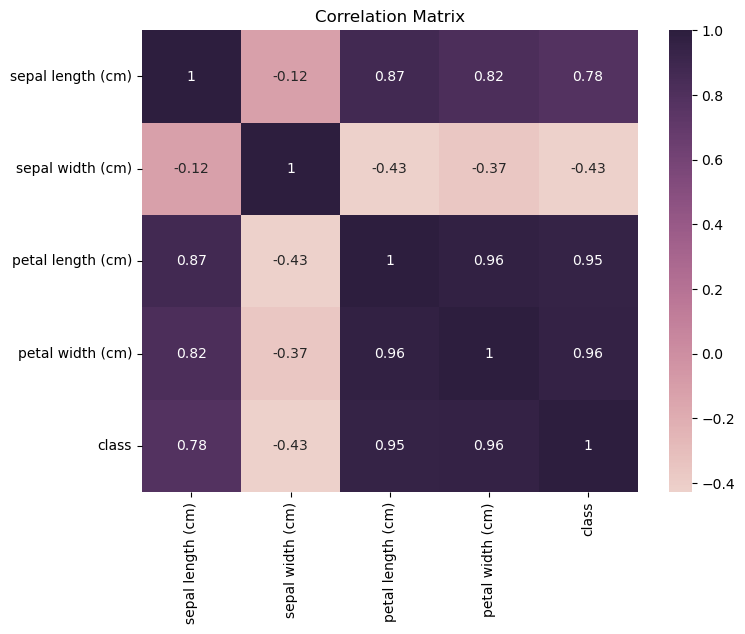

In [24]:
# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
plt.title('Correlation Matrix')
plt.show()

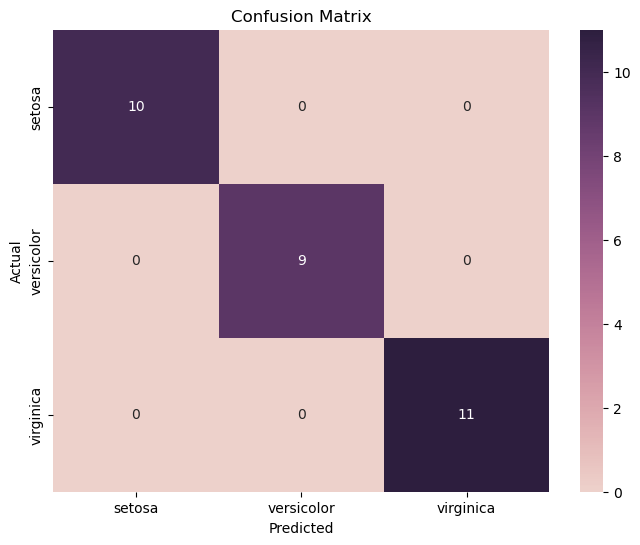

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",  cmap=sns.cubehelix_palette(as_cmap=True),
            xticklabels=names, yticklabels=names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
# If the accuracy is less than expected, check if the variance is high. If so standardize the data and use the euclidean metric
# knn1=KNeighborsClassifier(n_neighbors=5, metric='euclidean')
# knn1.fit(X_train,y_train)
# y_pred2=knn1.predict(X_test)
# accuracy_score(y_test, y_pred2)